In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy.io as sio
import os

# Paderborn 데이터셋 실습
2상 전류로 3상 전료 복원

I1 + I2 + I3 = 0

-> I3 = -(I1 + I2)

### 💡 문제 원인 분석 및 해결 코드
바로 위 셀에서 `sensor_arrays`가 비어있던 이유는, 기존 탐색 함수가 MATLAB 특유의 **'구조체 배열(Structured Array)'** 내부의 필드명(예: 'Y', 'Data' 등)을 파고드는 로직이 누락되어 있었기 때문입니다. `sio.loadmat`은 구조체를 단순 딕셔너리가 아닌 `dtype.names`를 가진 numpy 배열로 로드합니다.

아래 셀에는 구조체 필드까지 완벽하게 파고드는 **최종 업그레이드된 탐색 함수**가 포함되어 있습니다. 아래 셀을 실행해 보세요!


In [2]:
mat_file_path = 'K001/N09_M07_F10_K001_1.mat'
Fs = 64000 


if os.path.exists(mat_file_path):
    print(f"실제 Paderborn {mat_file_path} 파일을 불러옵니다.")
    mat_data = sio.loadmat(mat_file_path)
    
    # --- [업그레이드된 탐색 함수] MATLAB 구조체(Structured Array) 및 Dict 완벽 탐색 ---
    def extract_sensor_data(obj):
        arrays = []
        if isinstance(obj, np.ndarray):
            # 1. 만약 필드명(names)을 가진 구조체 배열이라면 필드 순회
            if obj.dtype.names is not None:
                for name in obj.dtype.names:
                    arrays.extend(extract_sensor_data(obj[name]))
            # 2. 객체(Object) 배열이라면 내부 요소를 순회
            elif obj.dtype == object:
                for item in obj.flatten():
                    arrays.extend(extract_sensor_data(item))
            # 3. 일반 숫자 배열인 경우 (우리가 찾는 실제 센서 데이터)
            else:
                if obj.size > 10000 and (obj.ndim == 1 or obj.shape[0] == 1 or obj.shape[1] == 1):
                    arrays.append(obj.flatten())
        # 4. 딕셔너리 형태일 경우 (가장 바깥쪽 구조)
        elif isinstance(obj, dict):
            for k, v in obj.items():
                if not k.startswith('__'):
                    arrays.extend(extract_sensor_data(v))
        return arrays
    
    # 함수 실행 (최상위 mat_data를 바로 넣어도 알아서 찾아냅니다)
    sensor_arrays = extract_sensor_data(mat_data)
    
    print(f"총 {len(sensor_arrays)}개의 센서 채널 데이터를 찾아냈습니다!")
    
    if len(sensor_arrays) >= 2:
        # Paderborn은 보통 전류1, 전류2, 진동 데이터 등을 가집니다.
        phase1_current = sensor_arrays[0][:64000] # 1초 분량
        phase2_current = sensor_arrays[1][:64000]
        print("전류 추출 성공!")
    else:
        print("센서 데이터를 2개 이상 찾지 못했습니다.")
else:
    print(f"파일을 찾을 수 없습니다: {mat_file_path}")


실제 Paderborn K001/N09_M07_F10_K001_1.mat 파일을 불러옵니다.
총 8개의 센서 채널 데이터를 찾아냈습니다!
전류 추출 성공!


In [3]:
# 3상 전료 추출
print(phase1_current.shape)
print(phase2_current.shape)
# phase3_current = -(phase1_current + phase2_current)
# data_3ch = np.column_stack([phase1_current, phase2_current, phase3_current])
# print("데이터 Shape (1초 분량, 3상 전류):", data_3ch.shape)

(16008,)
(64000,)


### 💡 문제 원인 분석 및 해결 코드 (길이 불일치 문제)
정확한 지적이십니다! 16008개가 나온 이유는 Paderborn 데이터셋 안에 전류/진동 뿐만 아니라 **속도(Speed), 토크(Torque)** 등의 보조 센서 데이터도 함께 들어있기 때문입니다. 보조 센서들은 샘플링 속도가 4kHz라서 4초 분량이 약 16000개인 반면, 64kHz인 전류/진동 센서는 256000개의 길이를 가집니다.

기존 코드가 발견된 순서대로 0번, 1번을 가져오다 보니 '속도 센서(16008개)'와 '전류 센서(256000개)'를 짝지어 버린 것입니다.
아래 코드는 **가장 긴 길이(256000개)를 가진 고주파 배열만 골라내어 전류를 정확히 매칭**하는 최종 해결 코드입니다.


In [4]:
import os
import scipy.io as sio
import numpy as np

mat_file_path = 'K001/N09_M07_F10_K001_1.mat'

if os.path.exists(mat_file_path):
    print(f"실제 Paderborn {mat_file_path} 파일을 불러옵니다.")
    mat_data = sio.loadmat(mat_file_path)
    
    def extract_sensor_data(obj):
        arrays = []
        if isinstance(obj, np.ndarray):
            if obj.dtype.names is not None:
                for name in obj.dtype.names:
                    arrays.extend(extract_sensor_data(obj[name]))
            elif obj.dtype == object:
                for item in obj.flatten():
                    arrays.extend(extract_sensor_data(item))
            else:
                if obj.size > 10000 and (obj.ndim == 1 or obj.shape[0] == 1 or obj.shape[1] == 1):
                    arrays.append(obj.flatten())
        elif isinstance(obj, dict):
            for k, v in obj.items():
                if not k.startswith('__'):
                    arrays.extend(extract_sensor_data(v))
        return arrays
    
    sensor_arrays = extract_sensor_data(mat_data)
    
    # --- [핵심 수정] 길이가 가장 긴 고주파 배열(전류, 진동)만 필터링 ---
    max_length = max(len(arr) for arr in sensor_arrays)
    high_freq_arrays = [arr for arr in sensor_arrays if len(arr) == max_length]
    
    print(f"전체 탐색된 배열: {len(sensor_arrays)}개")
    print(f"고주파 배열(길이 {max_length}): {len(high_freq_arrays)}개 추출됨")
    
    if len(high_freq_arrays) >= 2:
        # Paderborn은 보통 고주파 배열 중 0번이 Phase 1, 1번이 Phase 2 전류입니다.
        phase1_current = high_freq_arrays[0][:64000] # 1초 분량
        phase2_current = high_freq_arrays[1][:64000]
        
        print(f"Phase 1 전류 길이: {len(phase1_current)}")
        print(f"Phase 2 전류 길이: {len(phase2_current)}")
        
        # 3상 전류(Phase 3) 완벽 복원
        phase3_current = -(phase1_current + phase2_current)
        data_3ch = np.column_stack([phase1_current, phase2_current, phase3_current])
        print("최종 3상 전류 데이터 Shape:", data_3ch.shape)
    else:
        print("전류 데이터를 추출하기에 충분한 고주파 배열이 없습니다.")
else:
    print(f"파일을 찾을 수 없습니다: {mat_file_path}")


실제 Paderborn K001/N09_M07_F10_K001_1.mat 파일을 불러옵니다.
전체 탐색된 배열: 8개
고주파 배열(길이 256823): 4개 추출됨
Phase 1 전류 길이: 64000
Phase 2 전류 길이: 64000
최종 3상 전류 데이터 Shape: (64000, 3)


In [ ]:
def preprocess_stft_for_cnn(sensor_data_3ch, fs, nperseg=256, noverlap=128):
    """
    핵심 주의점 1 반영: 개별 정규화가 아닌 '글로벌 정규화' 수행
    """
    # 1. 3상 전체의 STFT 결과를 일단 모아둡니다.
    all_mag_db = []
    f_out, t_out = None, None
    
    for i in range(3):
        f, t, Zxx = signal.stft(sensor_data_3ch[:, i], fs=fs, nperseg=nperseg, noverlap=noverlap)
        mag = np.abs(Zxx)
        mag_db = 20 * np.log10(mag + 1e-10) # dB 변환
        
        all_mag_db.append(mag_db)
        if f_out is None: f_out, t_out = f, t
            
    # 2. 리스트를 3D 배열(Freq, Time, 3 Channels)로 변환
    stft_3d = np.stack(all_mag_db, axis=-1)
    
    # 3. 글로벌 정규화 (전체 3상 데이터 통틀어 가장 큰 값/작은 값 기준)
    global_max = np.max(stft_3d)
    global_min = np.min(stft_3d)
    
    stft_image_normalized = (stft_3d - global_min) / (global_max - global_min)
    
    return f_out, t_out, stft_image_normalized

# nperseg=2048 로 설정 (64kHz 샘플링에서는 nperseg가 커야 주파수 해상도(약 31.25Hz)가 나옵니다)
f, t, stft_image = preprocess_stft_for_cnn(data_3ch, Fs, nperseg=2048, noverlap=1024)

print("최종 CNN 입력용 STFT Tensor Shape (Freq, Time, Channels):", stft_image.shape)


최종 CNN 입력용 STFT Tensor Shape (Freq, Time, Channels): (1025, 64, 3)


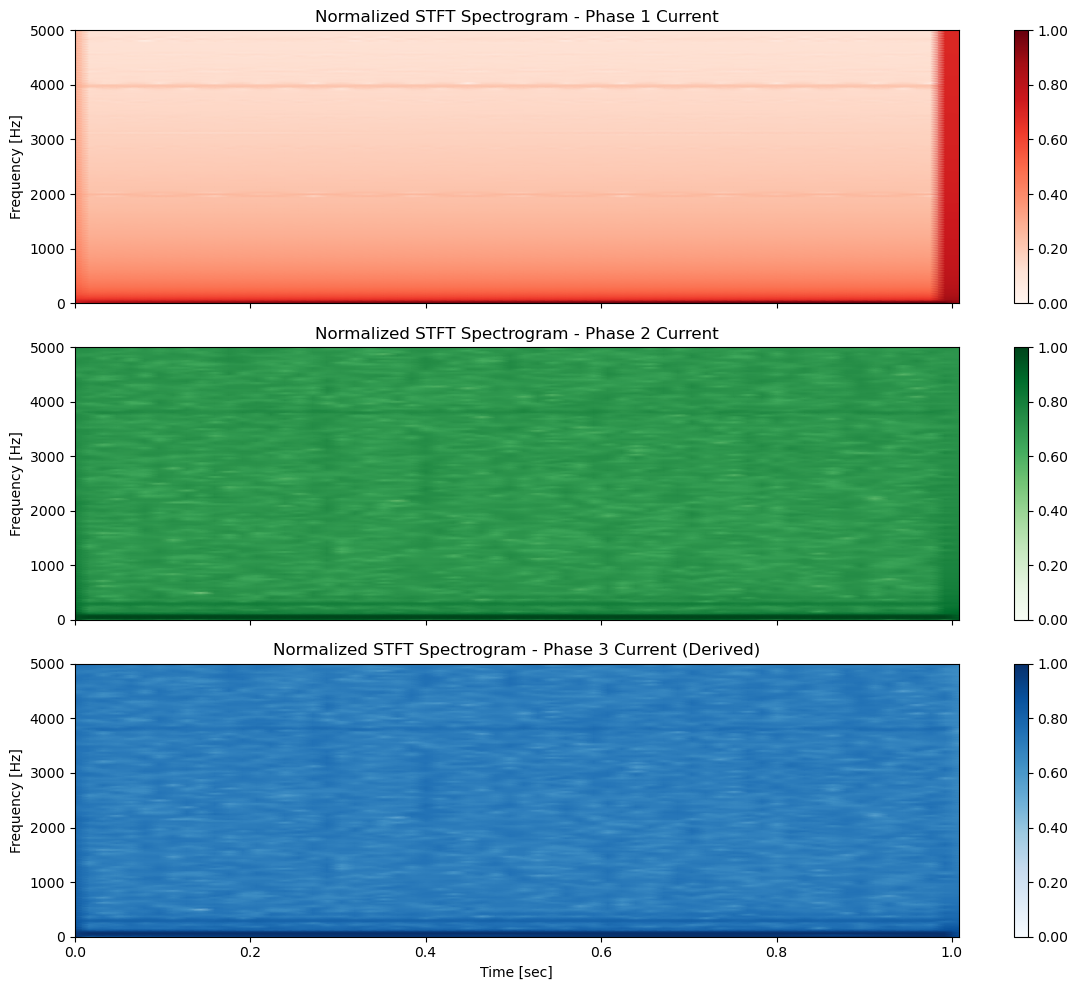

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
channel_names = ['Phase 1 Current', 'Phase 2 Current', 'Phase 3 Current (Derived)']
colors = ['Reds', 'Greens', 'Blues']

for i in range(3):
    # 정규화된 2D 배열의 상별 시각화 (vmin=0, vmax=1 고정)
    mesh = axes[i].pcolormesh(t, f, stft_image[:, :, i], shading='gouraud', cmap=colors[i], vmin=0, vmax=1)
    axes[i].set_ylabel('Frequency [Hz]')
    axes[i].set_title(f'Normalized STFT Spectrogram - {channel_names[i]}')
    
    # 64kHz 나이퀴스트 주파수는 32000Hz지만, 모터 고장 패턴은 주로 5000Hz 이하 대역에서 관찰됩니다.
    axes[i].set_ylim([0, 5000]) 
    fig.colorbar(mesh, ax=axes[i], format='%.2f')

axes[-1].set_xlabel('Time [sec]')
plt.tight_layout()
plt.show()

In [ ]:
import os
import scipy.io as sio
import numpy as np


mat_file_path = 'K001/N09_M07_F10_K001_1.mat'

Fs = 64000

if os.path.exists(mat_file_path):
    print(f"실제 Paderborn {mat_file_path} 파일을 불러옵니다.")
    mat_data = sio.loadmat(mat_file_path)
    
    def extract_sensor_data(obj):
        arrays = []
        if isinstance(obj, np.ndarray):
            if obj.dtype.names is not None:
                for name in obj.dtype.names:
                    arrays.extend(extract_sensor_data(obj[name]))
            elif obj.dtype == object:
                for item in obj.flatten():
                    arrays.extend(extract_sensor_data(item))
            else:
                if obj.size > 10000 and (obj.ndim == 1 or obj.shape[0] == 1 or obj.shape[1] == 1):
                    arrays.append(obj.flatten())
        elif isinstance(obj, dict):
            for k, v in obj.items():
                if not k.startswith('__'):
                    arrays.extend(extract_sensor_data(v))
        return arrays
    
    sensor_arrays = extract_sensor_data(mat_data)
    
    # --- [핵심 수정] 길이가 가장 긴 고주파 배열(전류, 진동)만 필터링 ---
    max_length = max(len(arr) for arr in sensor_arrays)
    high_freq_arrays = [arr for arr in sensor_arrays if len(arr) == max_length]
    
    print(f"전체 탐색된 배열: {len(sensor_arrays)}개")
    print(f"고주파 배열(길이 {max_length}): {len(high_freq_arrays)}개 추출됨")
    
    if len(high_freq_arrays) >= 2:
        # Paderborn은 보통 고주파 배열 중 0번이 Phase 1, 1번이 Phase 2 전류입니다.
        phase1_current = high_freq_arrays[0][:64000] # 1초 분량
        phase2_current = high_freq_arrays[1][:64000]
        
        print(f"Phase 1 전류 길이: {len(phase1_current)}")
        print(f"Phase 2 전류 길이: {len(phase2_current)}")
        
        # 3상 전류(Phase 3) 완벽 복원
        phase3_current = -(phase1_current + phase2_current)
        data_3ch = np.column_stack([phase1_current, phase2_current, phase3_current])
        print("최종 3상 전류 데이터 Shape:", data_3ch.shape)
    else:
        print("전류 데이터를 추출하기에 충분한 고주파 배열이 없습니다.")
else:
    print(f"파일을 찾을 수 없습니다: {mat_file_path}")


def preprocess_stft_for_cnn(sensor_data_3ch, fs, nperseg=256, noverlap=128):
    """
    핵심 주의점 1 반영: 개별 정규화가 아닌 '글로벌 정규화' 수행
    """
    # 1. 3상 전체의 STFT 결과를 일단 모아둡니다.
    all_mag_db = []
    f_out, t_out = None, None
    
    for i in range(3):
        f, t, Zxx = signal.stft(sensor_data_3ch[:, i], fs=fs, nperseg=nperseg, noverlap=noverlap)
        mag = np.abs(Zxx)
        mag_db = 20 * np.log10(mag + 1e-10) # dB 변환
        
        all_mag_db.append(mag_db)
        if f_out is None: f_out, t_out = f, t
            
    # 2. 리스트를 3D 배열(Freq, Time, 3 Channels)로 변환
    stft_3d = np.stack(all_mag_db, axis=-1)
    
    # 3. 글로벌 정규화 (전체 3상 데이터 통틀어 가장 큰 값/작은 값 기준)
    global_max = np.max(stft_3d)
    global_min = np.min(stft_3d)
    
    stft_image_normalized = (stft_3d - global_min) / (global_max - global_min)
    
    return f_out, t_out, stft_image_normalized

# nperseg=2048 로 설정 (64kHz 샘플링에서는 nperseg가 커야 주파수 해상도(약 31.25Hz)가 나옵니다)
f, t, stft_image = preprocess_stft_for_cnn(data_3ch, Fs, nperseg=2048, noverlap=1024)

print("최종 CNN 입력용 STFT Tensor Shape (Freq, Time, Channels):", stft_image.shape)


실제 Paderborn K001/N09_M07_F10_K001_1.mat 파일을 불러옵니다.
전체 탐색된 배열: 8개
고주파 배열(길이 256823): 4개 추출됨
Phase 1 전류 길이: 64000
Phase 2 전류 길이: 64000
최종 3상 전류 데이터 Shape: (64000, 3)
최종 CNN 입력용 STFT Tensor Shape (Freq, Time, Channels): (1025, 64, 3)


### 최종 - 정상 데이터 텐서 일괄 추출 및 저장 (.npy)
학습용 데이터를 구축하기 위해 `K001` 폴더 내의 모든 `.mat` 파일을 순회하면서 STFT 변환을 수행하고, 결과를 `normal_image` 폴더에 저장하는 코드입니다.

* 딥러닝 모델에 직접 입력하기 위해 값의 손실이 없는 **`.npy` (Numpy 배열) 형태**로 저장합니다.
* 눈으로 확인할 수 있도록 **`.png` 이미지 파일**도 함께 저장합니다.
* 4초(256,000개)짜리 데이터를 **1초(64,000개)씩 4등분(Chunk)**하여 데이터 개수를 4배로 늘립니다!


In [4]:
import glob
import matplotlib.pyplot as plt

# # 1. 저장할 폴더 생성
save_dir = 'normal_image'
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)

# 2. K001 폴더 안의 모든 .mat 파일 검색
mat_files = glob.glob('K001/*.mat')
print(f"총 {len(mat_files)}개의 정상 .mat 파일을 찾았습니다. 변환을 시작합니다...")

# 카운터
total_saved = 0

for mat_file in mat_files:
    filename = os.path.basename(mat_file).replace('.mat', '')
    mat_data = sio.loadmat(mat_file)
    
    # 이전에 정의한 탐색 함수 사용
    sensor_arrays = extract_sensor_data(mat_data)
    
    # 가장 긴 고주파 배열(전류) 필터링
    if len(sensor_arrays) == 0: continue
    max_length = max(len(arr) for arr in sensor_arrays)
    high_freq_arrays = [arr for arr in sensor_arrays if len(arr) == max_length]
    
    if len(high_freq_arrays) >= 2:
        phase1_full = high_freq_arrays[0]
        phase2_full = high_freq_arrays[1]
        
        # 4초 데이터를 1초(64000개)씩 쪼개기 (데이터 증강)
        chunks = len(phase1_full) // 64000
        for chunk_idx in range(chunks):
            start = chunk_idx * 64000
            end = start + 64000
            
            p1_chunk = phase1_full[start:end]
            p2_chunk = phase2_full[start:end]
            p3_chunk = -(p1_chunk + p2_chunk) # 3상 복원
            
            data_3ch = np.column_stack([p1_chunk, p2_chunk, p3_chunk])
            
            # STFT 변환 및 글로벌 정규화
            _, _, stft_img = preprocess_stft_for_cnn(data_3ch, Fs, nperseg=2048, noverlap=1024)
            
            # 파일명 지정
            save_name = f"{filename}_chunk{chunk_idx}"
            
            # 1. Numpy 배열로 저장 (CNN 학습용, 데이터 손실 0%)
            np.save(os.path.join(save_dir, save_name + '.npy'), stft_img)
            
            # 2. PNG 이미지로 저장 (눈으로 확인용)
            # plt.imsave(os.path.join(save_dir, save_name + '.png'), stft_img, origin='lower')
            
            total_saved += 1
            
    print(f"[{filename}] 처리 완료")

print(f"\n 모든 변환 완료 총 {total_saved}개의 STFT 텐서와 이미지가 '{save_dir}' 폴더에 저장 완료")


총 80개의 정상 .mat 파일을 찾았습니다. 변환을 시작합니다...
[N09_M07_F10_K001_1] 처리 완료
[N09_M07_F10_K001_10] 처리 완료
[N09_M07_F10_K001_11] 처리 완료
[N09_M07_F10_K001_12] 처리 완료
[N09_M07_F10_K001_13] 처리 완료
[N09_M07_F10_K001_14] 처리 완료
[N09_M07_F10_K001_15] 처리 완료
[N09_M07_F10_K001_16] 처리 완료
[N09_M07_F10_K001_17] 처리 완료
[N09_M07_F10_K001_18] 처리 완료
[N09_M07_F10_K001_19] 처리 완료
[N09_M07_F10_K001_2] 처리 완료
[N09_M07_F10_K001_20] 처리 완료
[N09_M07_F10_K001_3] 처리 완료
[N09_M07_F10_K001_4] 처리 완료
[N09_M07_F10_K001_5] 처리 완료
[N09_M07_F10_K001_6] 처리 완료
[N09_M07_F10_K001_7] 처리 완료
[N09_M07_F10_K001_8] 처리 완료
[N09_M07_F10_K001_9] 처리 완료
[N15_M01_F10_K001_1] 처리 완료
[N15_M01_F10_K001_10] 처리 완료
[N15_M01_F10_K001_11] 처리 완료
[N15_M01_F10_K001_12] 처리 완료
[N15_M01_F10_K001_13] 처리 완료
[N15_M01_F10_K001_14] 처리 완료
[N15_M01_F10_K001_15] 처리 완료
[N15_M01_F10_K001_16] 처리 완료
[N15_M01_F10_K001_17] 처리 완료
[N15_M01_F10_K001_18] 처리 완료
[N15_M01_F10_K001_19] 처리 완료
[N15_M01_F10_K001_2] 처리 완료
[N15_M01_F10_K001_20] 처리 완료
[N15_M01_F10_K001_3] 처리 완료
[N15_M01_F10_K001_4] 